# 9 변환영역 처리
변환영역은 직교 변환에 의해 얻어진 영상 데이터의 다른 표현이다. 화소값이 아닌 변환계수로 표현된다. 대표적으로 DCT, DFT가 있다. 여기서 푸리에 변환이 중요한데 시간(혹은 공간) 영역에서 주파수 영역으로의 변환으로, "모든 파형은 단순한 정현파의 합으로 구성된다"라는 개념에 기초한 해석적 방법이다.  

# 9.1 공간 주파수의 이해
주파수는 이벤트가 주기적으로 재발생하는 빈도라 한다. 영상에서 화소 밝기의 변화 정도를 파형으로 그릴 수 있고 이는 신호의 주파수와 같은 의미가 된다. 이 의미를 영상 신호에 확장하면 영상에서 주파수는 *** 공간 상에서 화소 밝기의 변화율 *** 이라 할 수 있고 공간 주파수로 표현한다.  
공간 주파수는 밝기의 변화 속도에 따라 고, 저주파 영역으로 분류한다. 저주파 공간 영역은 주로 배경, 객체의 내부에 많고 고주파 영역은 경계부분이나 객체의 모서리 부분에 많다.  
변환을 통해서 영상을 주파수 영역별로 분리할 수 있으면 영역별 처리가 가능하고 만약 경계 부분에 고주파 성분을 제거하면 경계가 흐려지게 할 수도 있고 저주파 성분을 제거하면 에지 영상이 만들어질 수도 있다.  
하지만 실제 영상들은 고, 저주파 성분이 섞여있어 분리하여 선별적으로 처리하기 어려워서 변환 영역의 처리가 필요하다.
크게 보면 이런 과정을 거친다. 입력 영상을 주파수 영역으로 변환 -> 계수의 특정 주파수 영역에 원하는 영상처리 적용 -> 주파수 역변환으로 공간영역의 영상 변환  

# 9.2 DFT
푸리에 변환은 신호나 영상을 주파수 영역으로 변환 하는 방법으로 다음의 전제를 기본으로 한다. "주기를 가진 신호는 정현파/여현파의 합으로 표현할 수 있다." 여기서 정현파/여현파는 모든 파형 중 가장 순수한 파형으로 사인, 코사인 함수의 신호를 말한다. 즉 사인, 코사인 함수의 선형 조합으로 특정 주기의 신호를 구성할 수 있다.  
반대로 어떤 주기를 갖는 신호도 여러 개의 사인, 코사인 함수들로 분리할 수 있고 분리된 신호는 기저 함수가 되고 기저 함수에 곱해지는 비율은 각 주파수의 계수(= 크기)가 된다. 정리하면 신호 -> 주파수는 각 주파수의 기저 함수들에 대한 계수를 찾는 것, 주파수 -> 신호 기저함수와 계수들로 원본 신호를 찾는 것이다.  
이렇게 DFT를 적용한 주파수 스펙트럼 영상은 저주파 영역의 계수 값이 상대적으로 크다. 그래서 계수 값을 일반적인 방법으로 정규화 해서 표현하면 최저주파 영역만 흰색으로 나타나고 나머지는 거의 검은 색으로 나타나 영상으로 확인하기 어렵다. 그래서 계수 값을 로그화 한다.  
그리고 DFT 수행 후 주파수 스펙트럼 영상은 저주파 영역이 영상의 모서리 부분에 위치하고 고주차 부분이 중심에 있는데 이러면 주파수 영역의 처리가 불편하여 셔플링, 시프트 연산이라고 하는 과정을 수행한다.  

In [50]:
import numpy as np, cv2, math, time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.fftpack as sf

In [22]:
def exp(knN):
    th = -2 * math.pi * knN
    return complex(math.cos(th), math.sin(th))

def dft(g):
    N = len(g)
    dst = [sum(g[n] *exp(k*n/N) for n in range(N)) for k in range(N)]
    return np.array(dst)

def idft(g):
    N = len(g)
    dst = [sum(g[n] * exp(-k*n/N) for n in range(N)) for k in range(N)]
    return np.array(dst) / N

def calc_spectrum(complex):
    if complex.ndim == 2:
        dst = abs(complex)
    else:
        dst = cv2.magnitude(complex[:, :, 0], complex[:, :, 1])
    dst = cv2.log(dst + 1)
    cv2.normalize(dst, dst, 0, 255, cv2.NORM_MINMAX)
    return cv2.convertScaleAbs(dst)

def fftshift(img):
    dst = np.zeros(img.shape, img.dtype)
    h, w = dst.shape[:2]
    cy, cx = h // 2, w // 2
    dst[h-cy:, w-cx:] = np.copy(img[0:cy, 0:cx])
    dst[0:cy, 0:cx] = np.copy(img[h-cy:, w-cx:])
    dst[0:cy, w-cx:] = np.copy(img[h-cy:, 0:cx])
    dst[h-cy:, 0:cx] = np.copy(img[0:cy, w-cx:])
    return dst

In [23]:
def dft2(img):
    tmp = [dft(row) for row in img]
    dst = [dft(row) for row in np.transpose(tmp)]
    return np.transpose(dst)

def idft2(img):
    tmp = [idft(row) for row in img]
    dst = [idft(row) for row in np.transpose(tmp)]
    return np.transpose(dst)

def ck_time(mode=0):
    global stime
    if (mode == 0):
        stime = time.perf_counter()
    elif (mode == 1):
        etime = time.perf_counter()
        print("elapsed time: %.5f sec" % (etime - stime))

In [15]:
img = cv2.imread("../images/timetable.jpg", cv2.IMREAD_GRAYSCALE)

ck_time(0)
dft = dft2(img)
spect1 = calc_spectrum(dft)
spect2 = fftshift(spect1)
idft = idft2(dft).real
ck_time(1)

titles = ['img', 'spect1', 'spect2', 'idft']
fig, axs = plt.subplots(nrows=1, ncols=4)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

# 9.3 FFT
DFT는 원본 신호의 한 원소에 곱하는 기저 함수의 원소들은 원소 길이 만큼 반복적으로 곱해지기 때문에 신호가 커질수록 계산 속도는 기하급수적으로 증가한다. 즉 DFT의 꼴이 계수와 e^ix가 곱해지고 더해지는 꼴이므로 신호가 커질 수록 계산 속도가 올라간다는 것이다.  
FFT는 삼각함수의 주기성을 이용해서 작은 단위로 반복적으로 분리해서 수행하여 합하여 효율성을 높인다. 대략적으로 설명하면 홀수 원소와 짝수 원소로 나누어 계산하는데 계산하다가 보면 2pi가 나오기 때문에 줄일 수 있다는 것이다. 이 과정을 한 번만 하는 것이 아니라 분할 할 수 있을 만큼 시행 후 합하는 것이다. 분할 정복 알고리즘을 이용해서 효율적으로 바꾸는 것이다.  
지금까지 나누는 과정을 보았고 병합할 때는 버터플라이 과정을 거친다. 이 과정은 원본 신호의 길이가 2개 원소를 가질 때까지 분리하며 분리 횟수만큼 연속적으로 반복한다. 그런데 원본 신호를 2개 원소를 가질 때까지 분리하기 때문에 원본 신호의 길이는 2의 지수승이 되어야 하지만 영상의 크기가 반드시 2의 자승이 아닌 문제가 있어서 영삽입을 통해서 해결한다. 이런 방법이 가능한 이유는 푸리에 변환 결과인 주파수 스펙트럼이 평행이동에 영향을 받지 않기 때문이다.

In [26]:
def zeropadding(img):
    h, w = img.shape[:2]
    m = 1 << int(np.ceil(np.log2(h)))
    n = 1 << int(np.ceil(np.log2(w)))
    dst = np.zeros((m, n), img.dtype)
    dst[0:h, 0:w] = img[:]
    return dst

def butterfly(pair, L, N, dir):
    for k in range(L):
        Geven, Godd = pair[k], pair[k + L]
        pair[k] = Geven + Godd * exp(dir*k/N)
        pair[k + L] = Geven - Godd * exp(dir*k/N)

def pairing(g, N, dir, start=0, stride=1):
    if N == 1: return [g[start]]
    L = N // 2
    sd = stride * 2
    part1 = pairing(g, L, dir, start, sd)
    part2 = pairing(g, L, dir, start + stride, sd)
    pair = part1 + part2
    butterfly(pair, L, N, dir)
    return pair

def fft(g):
    return pairing(g, len(g), 1)

def ifft(g):
    fft = pairing(g, len(g), -1)
    return [v / len(g) for v in fft]

def fft2(img):
    pad_img = zeropadding(img)
    tmp = [fft(row) for row in pad_img]
    dst = [fft(row) for row in np.transpose(tmp)]
    return np.transpose(dst)

def ifft2(img):
    pad_img = zeropadding(img)
    tmp = [fft(row) for row in img]
    dst = [fft(row) for row in np.transpose(tmp)]
    return np.transpose(dst)

user transform mat size: (1024, 2048)
np.fft transform mat size: (1005, 1131)
cv2.dft transform mat size: (1005, 1131, 2)


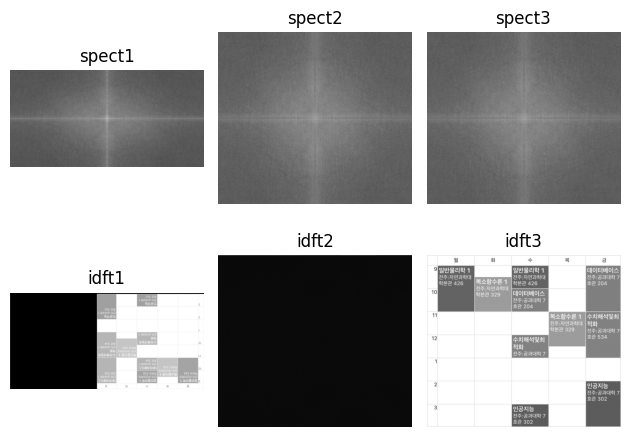

In [28]:
img = cv2.imread("../images/timetable.jpg", cv2.IMREAD_GRAYSCALE)

dft1 = fft2(img)
dft2 = np.fft.fft2(img)
dft3 = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

spect1 = calc_spectrum(fftshift(dft1))
spect2 = calc_spectrum(fftshift(dft2))
spect3 = calc_spectrum(fftshift(dft3))

idft1 = fft2(dft1).real
idft2 = np.fft.ifft(dft2).real
idft3 = cv2.idft(dft3, flags=cv2.DFT_SCALE)[:,:,0]

print("user transform mat size:", dft1.shape)
print("np.fft transform mat size:", dft2.shape)
print("cv2.dft transform mat size:", dft3.shape)

titles = ['spect1', 'spect2', 'spect3', 'idft1', 'idft2', 'idft3']
fig, axs = plt.subplots(nrows=2, ncols=3)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 9.4 FFT를 이용한 주파수 영역 필터링

## 9.4.1 주파수 영역 필터링 과정
영상을 2차원 푸리에 변환을 수행할 수 있다. 주파수 영역에서 필터링 과정은 푸리에 변환 계수에 필터 행렬을 원소간에 곱하여 수행된다. 그런데 여기서 푸리에 변환계수는 복소수이므로 실수부와 허수부 둘 다 실행 되어야 한다. 그리고 그 곱한 수행 결과를 푸리에 역변환 하여 공간영역의 영상으로 만들 수 있다. 이러한 과정을 주파수 성분 조작이라 하고 필터에 따라 저주파 통과 필터링, 고주파 통과 필터링, 등 을 쉽게 구현할 수 있다.  

## 9.4.2 저주파 및 고주파 통과 필터링
저주파 통과 필터링는 DFT 변환 영역에서 저주파 영역의 계수들은 통과시키고 그 이외의 영역 즉, 고주파 영역의 계수는 차단하는 것이다. 반대로 고주파 통과 필터링은 그 반대이다.  
셔플링을 수행해서 주파수 스펙트럼 영상을 보면 중심 부분이 저주파 영역이며, 외곽으로 갈수록 고주파 영역이다. 그래서 저주파 통과 필터링은 중심이 지정된 반지름 크기의 원형으로 1을 갖게하여 통과 시키고 가장자리 부분은 1로 지정하여 통과 시킨다.  

In [37]:
def FFT(img, mode = 2):
    if mode == 1: dft = fft2(img)
    elif mode == 2: dft = np.fft.fft2(img)
    elif mode == 3: dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft = fftshift(dft)
    spectrum = calc_spectrum(dft)
    return dft, spectrum

def IFFT(dft, shape, mode=2):
    dft = fftshift(dft)
    if mode == 1: img = fft2(dft).real
    elif mode == 2: img = np.fft.ifft2(dft).real
    elif mode == 3: img = cv2.idft(dft, flags=cv2.DFT_SCALE)[:, :, 0]
    img = img[:shape[0], :shape[1]]
    return cv2.convertScaleAbs(img)

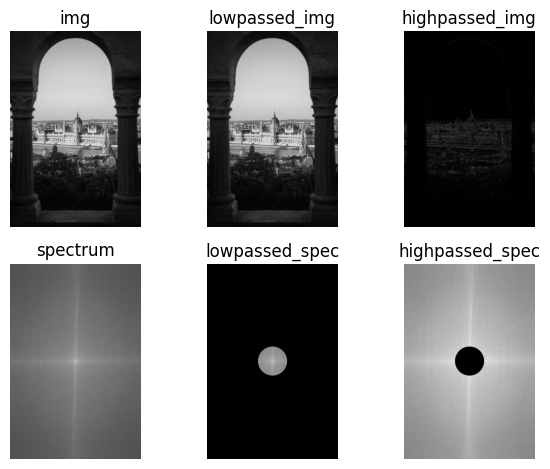

In [43]:
img = cv2.imread("../images/castle.jpg", cv2.IMREAD_GRAYSCALE)

cy, cx = np.divmod(img.shape, 2)[0]
mode = 2

dft, spectrum = FFT(img, mode)
lowpass = np.zeros(dft.shape, np.float32)
highpass = np.ones(dft.shape, np.float32)
cv2.circle(lowpass, (cx, cy), 200, (1, 1), -1)
cv2.circle(highpass, (cx, cy), 200, (0, 0), -1)

lowpassed_dft = dft * lowpass
highpassed_dft = dft * highpass
lowpassed_img = IFFT(lowpassed_dft, img.shape, mode)
highpassed_img = IFFT(highpassed_dft, img.shape, mode)

lowpassed_spec = calc_spectrum(lowpassed_dft)
highpassed_spec = calc_spectrum(highpassed_dft)

titles = ['img', 'lowpassed_img', 'highpassed_img', 'spectrum', 'lowpassed_spec', 'highpassed_spec']
fig, axs = plt.subplots(nrows=2, ncols=3)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9.4.3 버터워스, 가우시안 필터링
9.4.2의 대역 통과 필터는 특정한 대역에서 급격하게 값을 제거하여서 화질이 좋지 못하다. 특히 저주파 통과 필터링의 경우에 영상에서 객체의 경계부분이 완만해지긴 하지만 경계부분 주위로 잔물결 같은 무늬가 나타나 화질이 떨어진다.  
이 문제를 해결하려면 필터 원소의 값을 0으로 만들지 않고 완만한 경사를 이루도록 구성하면 된다. 이 방식을 버터워스 필터, 가우시안 필터가 있다.  
가우시안 필터는 필터 원소의 구성을 가우시안 함수의 수식 분포를 가지게 하여 차단 주파수 부분을 점진적으로 구성한다. 가우시안 함수의 표준편차를 주파수를 차단할 반지름의 위치로 간주하면 필터를 만들 수 있다.  
버터워스 필터도 기능은 같지만 수식에 차이가 있다.

In [47]:
def get_gaussianFilter(shape, R):
    u = np.array(shape) // 2
    y  = np.arange(-u[0], u[0], 1)
    x = np.arange(-u[1], u[1], 1)
    x, y = np.meshgrid(x, y)
    filter = np.exp(-(x**2 + y**2) / (2* R**2))
    return x, y, filter if len(shape) < 3 else cv2.merge([filter, filter])

def get_butterworthFilter(shape, R, n):
    u = np.array(shape) // 2
    y  = np.arange(-u[0], u[0], 1)
    x = np.arange(-u[1], u[1], 1)
    x, y = np.meshgrid(x, y)
    dist = np.sqrt(x**2 + y**2)
    filter = 1 / (1 + np.power(dist / R, 2 * n))
    return x, y, filter if len(shape) < 3 else cv2.merge([filter, filter])

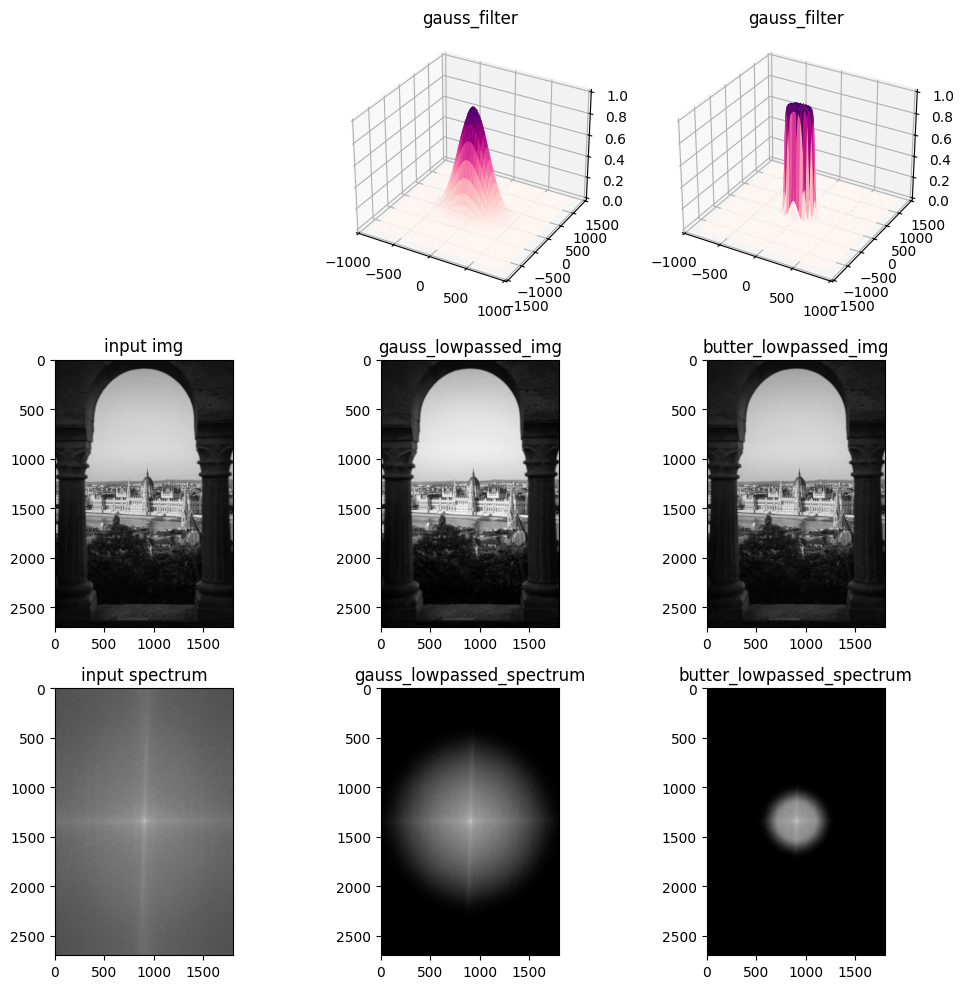

In [49]:
img = cv2.imread("../images/castle.jpg", cv2.IMREAD_GRAYSCALE)

mode = 2
dft, spectrum = FFT(img, mode)
x1, y1, gauss_filter = get_gaussianFilter(dft.shape, 200)
x2, y2, butter_filter = get_butterworthFilter(dft.shape, 200, 10)

filtered_dft1 = dft * gauss_filter
filtered_dft2 = dft * butter_filter
gauss_img = IFFT(filtered_dft1, img.shape, mode)
butter_img = IFFT(filtered_dft2, img.shape, mode)
spectrum1 = calc_spectrum(filtered_dft1)
spectrum2 = calc_spectrum(filtered_dft2)

if mode == 3:
    gauss_filter, butter_filter = gauss_filter[:, :, 0], butter_filter[:, :, 0]

plt.figure(figsize=(10,10))
ax1 = plt.subplot(332, projection='3d')
ax1.plot_surface(x1, y1, gauss_filter, cmap='RdPu')
plt.title("gauss_filter")

ax2 = plt.subplot(333, projection='3d')
ax2.plot_surface(x2, y2, butter_filter, cmap='RdPu')
plt.title("gauss_filter")

titles = ['input img', 'gauss_lowpassed_img', 'butter_lowpassed_img',
            'input spectrum', 'gauss_lowpassed_spectrum', 'butter_lowpassed_spectrum']
imgs = [img, gauss_img, butter_img, spectrum, spectrum1, spectrum2]
plt.gray()
for i, t in enumerate(titles):
    plt.subplot(3, 3, i+4)
    plt.imshow(imgs[i])
    plt.title(t)
plt.tight_layout()
plt.show()

푸리에 변환을 이용해서 모아레 잡음도 제거할 수 있다. 모아레란 두 개 이상의 주기적인 패턴이 겹쳐질 때 만들어지는 간섭 무늬를 지칭하는 말이다.

# 9.5 DCT
영상 압축에 효과적인 주파수 변환 법 중 하나이다. DFT는 실수부에 코사인함수 허수부에는 사인 함수가 곱해져서 이루어진다. 반면 DCT는 실수부만 취하고 허수부를 제외하는 직교 변환 방법이다.
DCT는 전체 영상을 한 번에 변환시키는 것이 아니라 영상을 작은 블록으로 나누어서 블록 단위로 수행한다. 이 블록의 크기를 키울 수록 압축의 효율이 높아지지만 변환의 구현이 어렵고 속도가 느려져서 8x8 크기가 성능과 구현 용이성간에 상호보완이 도어 표준으로 사용한다.

In [63]:
def cos(n, k, N):
    return math.cos((n+1 / 2) * math.pi * k/N)

def C(k, N):
    return math.sqrt(1/N) if k == 0 else math.sqrt(2/N)

def dct(g):
    N = len(g)
    f = [C(k, N) * sum(g[n] * cos(n, k, N) for n in range(N)) for k in range(N)]
    return np.array(f, np.float32)

def idct(f):
    N = len(f)
    g = [sum(C(k, N) * f[k] * cos(n, k, N) for k in range(N)) for n in range(N)]
    return np.array(g)

def _dct2(img):
    tmp = [dct(row) for row in img]
    dst = [dct(row) for row in np.transpose(tmp)]
    return np.transpose(dst)

def _idct2(img):
    tmp = [idct(row) for row in img]
    dst = [idct(row) for row in np.transpose(tmp)]
    return np.transpose(dst)

def scipy_dct2(a):
    tmp = sf.dct(a, axis=0, norm='ortho')
    return sf.dct(tmp, axis=1, norm='ortho')

def scipy_idct2(a):
    tmp = sf.idct(a, axis=0, norm='ortho')
    return sf.idct(tmp, axis=1, norm='ortho')

In [74]:
block = np.zeros((4, 6), np.uint8)
cv2.randn(block, 128, 50)

dct1 = _dct2(block)
dct2 = scipy_dct2(block)
dct3 = sf.dctn(block, shape=block.shape, norm='ortho')
dct4 = cv2.dct(block.astype('float32'))

idct1 = _idct2(dct1)
idct2 = scipy_idct2(dct2)
idct3 = cv2.idct(dct3)
idct4 = sf.idctn(dct4, shape=dct4.shape, norm='ortho')

print('block=', block)
print('dct1=\n', dct1)
print('dct2=\n', dct2)
print('dct3=\n', dct3)
print('dct4=\n', dct4)

print()

print('idct1=\n', cv2.convertScaleAbs(idct1))
print('idct2=\n', cv2.convertScaleAbs(idct2))
print('idct3=\n', cv2.convertScaleAbs(idct3))
print('idct4=\n', cv2.convertScaleAbs(idct4))

block= [[ 61 157  67 111 183 131]
 [101 116 123 187 104 181]
 [124 135  98 150 250 143]
 [ 47 119 130  84 206  95]]
dct1=
 [[ 633.3972    -113.1163     -16.75        23.066027  -102.04666
    -3.9098778]
 [  -1.9871193    3.8072968   21.732048   -17.576021    28.775396
   -69.51249  ]
 [ -65.52384      1.477152   -12.249998   -25.923763   -72.31312
    33.52464  ]
 [  26.673363   -10.69643     26.987831    47.71268    -78.00439
    22.987759 ]]
dct2=
 [[ 633.39722265 -113.11629499  -16.75         23.06602841 -102.04666008
    -3.90987729]
 [  -1.98713443    3.80729716   21.73204957  -17.57602234   28.77539799
   -69.51249626]
 [ -65.52385062    1.47714743  -12.25        -25.92376644  -72.31312122
    33.52463824]
 [  26.67335681  -10.69642892   26.98783099   47.71268286  -78.00438964
    22.98775965]]
dct3=
 [[ 633.39722265 -113.11629499  -16.75         23.06602841 -102.04666008
    -3.90987729]
 [  -1.98713443    3.80729716   21.73204957  -17.57602234   28.77539799
   -69.51249626]
 [

(0, 0) 위치의 원소가 상대적으로 크고 나머지 값들은 작은 값을 가진다. 8x8 크기의 한 블록을 DCT 변환하면 64개의 주파수 계수가 구성된다. (0, 0) 위치를 DC 계수라고 하고 나머지 계수들을 AC 계수라고 한다.  
DC 계수는 공간 영역 화소값의 평균에 해당하는 값으로서 에너지가 집중되어 있고 DC 계수 주변 계수들은 영상의 주요 성분을 포함하고 있다.  
각 주파수 계수는 영상의 밝기 변화 특성을 나타낸다. 왼쪽 상단으로 갈 수록 저주파 영역이며, 오른쪽 하단으로 갈수록 고주파 영역이다. 저주파 영역으로 갈수록 밝기 변화가 적다.  
다음 코드는 DCT로 주파수 영역 필터링을 수행하는 것이다.

In [82]:
def dct2_mode(block, mode):
    if mode == 1: return _dct2(block)
    elif mode == 2: return scipy_dct2(block)
    elif mode == 3: return cv2.dct(block.astype('float32'))

def idct2_mode(block, mode):
    if mode == 1: return _idct2(block)
    elif mode == 2: return scipy_idct2(block)
    elif mode == 3: return cv2.idct(block)

def dct_filtering(img, filter, M, N):
    dst = np.empty(img.shape, np.float32)
    h, w = img.shape
    for i in range(0, h-M+1, M):
        for j in range(0, w-N+1, N):
            block = img[i:i+M, j:j+N]
            new_block = dct2_mode(block, mode)
            new_block = new_block * filter
            dst[i:i+M, j:j+N] = idct2_mode(new_block, mode)
    return cv2.convertScaleAbs(dst)

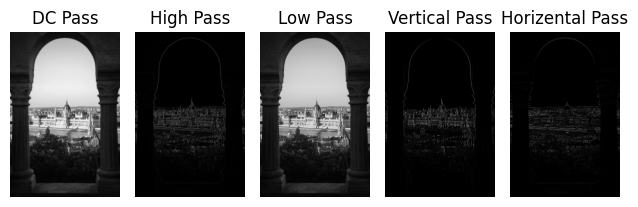

In [85]:
img = cv2.imread("../images/castle.jpg", cv2.IMREAD_GRAYSCALE)

mode = 2
M, N = 8, 8
filters = [np.zeros((M, N), np.float32) for i in range(5)]
titles = ['DC Pass', 'High Pass', 'Low Pass', 'Vertical Pass', 'Horizental Pass']

filters[0][0, 0] = 1
filters[1][:], filters[1][0, 0] = 1, 0
filters[2][:M//2, :N//2] = 1
filters[3][0, 1:] = 1
filters[4][1:, 0] = 1

fig, axs = plt.subplots(nrows=1, ncols=5)

for ax, filter, title in zip(axs.flat, filters, titles):
    dst = dct_filtering(img, filter, M, N)
    ax.imshow(dst, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

* DC Pass  
단지 DC 계수 하나의 원소만 통과 시키고, 다른 모든 계수를 차단한 필터링 영상이다. 그럼에도 원본 영상의 모습을 확인할 수 있을 정도로 DC계수는 블록 전체를 대표하는 값으로 에너지가 집중되어 있다.  
* Hign Pass  
DC Pass와 반대인데 저주파 영역을 제거하고 고주파 영역을 통과시키면 영상의 경계부분만 나타난다.  
* Low Pass  
저주파 통과 필터로 64개의 DCT 계수 중에 저주파 영역의 16개 계수만 통과시킨 것이다. 전체 계수의 1/4만 통과 시켰는데 원본영상과 크게 차이를 알 수 없을 정도로 화질이 좋다. 영상 압축에 유용하게 사용될 수 있는 가장 큰 특징이 된다.  
* Vertical Pass  
변환영역 상에 수평 방향 계수 성분만이 유지되기 때문에 영상 공간에서는 수직 방향의 에지만 표시된다.  
* Horizontal Pass  
변환영역 상에 수직 방향 계수 성분만이 유지되기 때문에 영상 공간에서는 수평 방향의 에지만 표시된다.